In [ ]:
!pip install Sastrawi

In [ ]:
!pip install nltk

In [ ]:
!pip install tqdm

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df = pd.read_csv('/content/mybca_reviews.csv')
df.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d3dc6f3c-80ea-4095-b514-3a8238d78570,sulis tyowati,https://play-lh.googleusercontent.com/a-/ALV-U...,baik,5,0,NaN,2026-04-12 09:10:35,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-04-12 09:34:34,NaN
1,de964e8a-e7de-48d4-b48e-a5fb985f7097,Bachtiar Fadil,https://play-lh.googleusercontent.com/a-/ALV-U...,baik,5,0,NaN,2026-04-12 09:08:24,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-04-12 09:34:36,NaN
2,eab16250-e7c1-4e0c-a90b-dde5599d2061,RADYTIA IRVING PRADIPTA,https://play-lh.googleusercontent.com/a/ACg8oc...,habi7 habis upgrade bukanya tambah bagus malah...,2,0,NaN,2026-04-12 08:42:19,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2026-04-12 09:15:01,NaN
3,20b76818-e49f-46fb-923f-52baba62a0b3,Er Pranajaya,https://play-lh.googleusercontent.com/a/ACg8oc...,LEMOOOOOOOOTTTTTTTTTTTT mau sampai kapan? gak ...,1,0,2.15.1,2026-04-12 08:21:01,Mohon maaf atas ketidaknyamanannya. Dipastikan...,2026-04-12 08:37:31,2.15.1
4,71265f80-7408-467f-86de-c8da033e1085,Fadzri Apryanto,https://play-lh.googleusercontent.com/a-/ALV-U...,tolong donk pas tambah nomer nyari nomer indo ...,2,0,2.15.1,2026-04-12 07:57:46,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-04-12 08:04:28,2.15.1


In [ ]:
df.shape

(20000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              20000 non-null  object
 1   userName              20000 non-null  object
 2   userImage             20000 non-null  object
 3   content               20000 non-null  object
 4   score                 20000 non-null  int64 
 5   thumbsUpCount         20000 non-null  int64 
 6   reviewCreatedVersion  15670 non-null  object
 7   at                    20000 non-null  object
 8   replyContent          20000 non-null  object
 9   repliedAt             20000 non-null  object
 10  appVersion            15670 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


In [ ]:
clean_df = df.dropna()

In [ ]:
clean_df = clean_df.drop_duplicates()

In [ ]:
numberof_review_after_deletedupe, numberof_column_after_deletedupe = clean_df.shape

In [ ]:
clean_df.shape

(15670, 11)

In [ ]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

In [ ]:
def normalize_repeated_char(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

In [ ]:
def casefoldingText(text):
    text = text.lower()
    return text

In [ ]:
def tokenizingText(text):
    text = word_tokenize(text)
    return text

In [ ]:
def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update([
        'iya','yaa','nya','na','sih','ku', 'aja', 'sih', 'si',
        'ya','loh','kah','woi','woii','woy', 'sihh', 'yah',
        'lah', 'ko', 'kok', 'yang', 'ke', 'di', 'd', 'dari',
        'ini', 'ni', 'itu', 'tuh', 'tu', 'nah', 'yaitu', 'adalah', 'mu',
        'deh', 'dong', 'kan', 'toh', 'pun', 'eh', 'ah', 'oh',
    ])

    if 'tidak' in listStopwords:
        listStopwords.remove('tidak')
    if 'ada' in listStopwords:
        listStopwords.remove('ada')

    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

In [ ]:
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [ ]:
slangwords = {
    "@": "di",
    "abis": "habis",
    "abs": "habis",
    "wtb": "beli",
    "masi": "masih",
    "wts": "jual",
    "wtt": "tukar",
    "bgt": "banget",
    "maks": "maksimal",
    "max": "maksimal",
    "min": "minimal",
    "udh": "sudah",
    "udah": "sudah",
    "uda": "sudah",
    "skrg": "sekarang",
    "tf": "transfer",
    "tranfer": "transfer",
    "emg": "memang",
    "mmg": "memang",
    "smlm": "semalam",
    "ngapa": "mengapa",
    "knp": "mengapa",
    "kenapa": "mengapa",
    "gimana": "bagaimana",
    "gmna": "bagaimana",
    "gmn": "bagaimana",
    "gmnnya": "bagaimana",
    "bngt": "banget",
    "tdak": "tidak",
    "tdk": "tidak",
    "g": "tidak",
    "ndak": "tidak",
    "ga": "tidak",
    "gaa": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "ngak": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "yg": "yang",
    "ni": "ini",
    "kesel": "kesal",
    "trus": "terus",
    "trs": "terus",
    "terimakasih": "terima kasih",
    "donk": "dong",
    "mantaf": "mantap",
    "nyari": "cari",
    "nomer": "nomor",
    "d": "di",
    "sy": "saya",
    "sya": "saya",
    "bsa": "bisa",
    "apk": "aplikasi",
    "apps": "aplikasi",
    "app": "aplikasi",
    "lemot": "lambat",
    "lelet": "lambat",
    "lag": "lambat",
    "ngelag": "lambat",
    "error": "kesalahan",
    "eror": "kesalahan",
    "err": "kesalahan",
    "crash": "berhenti",
    "force close": "berhenti",
    "fc": "berhenti",
    "login": "masuk",
    "log in": "masuk",
    "logout": "keluar",
    "otp": "kode otp",
    "verif": "verifikasi",
    "verifikasiin": "verifikasi",
    "konek": "terhubung",
    "koneksi": "koneksi",
    "gagal": "gagal",
    "gk bisa": "tidak bisa",
    "gabisa": "tidak bisa",
    "ga bisa": "tidak bisa",
    "ngga bisa": "tidak bisa",
    "ga kebuka": "tidak bisa dibuka",
    "gabuka": "tidak bisa dibuka",
    "kebuka": "dibuka",
    "update": "pembaruan",
    "upd": "pembaruan",
    "versi": "versi",
    "ribet": "rumit",
    "rempong": "rumit",
    "simple": "sederhana",
    "user friendly": "mudah digunakan",
    "friendly": "mudah digunakan",
    "burik": "buruk",
    "jelek": "buruk",
    "bagus banget": "sangat bagus",
    "ok": "baik",
    "oke": "baik",
    "okey": "baik",
    "helpful": "membantu",
    "ngebantu": "membantu",
    "bantu": "membantu",
    "loading": "memuat",
    "ngeload": "memuat",
    "stuck": "macet",
    "hang": "macet",
    "ngeload lama": "memuat lama",
    "kepake": "digunakan",
    "dipake": "digunakan",
    "pake": "pakai",
    "pakaiin": "pakai",
    "saldo": "saldo",
    "topup": "isi ulang",
    "top up": "isi ulang",
    "transferan": "transfer",
    "tfan": "transfer",
    "mutasi": "riwayat transaksi",
    "riwayat": "riwayat transaksi",
    "cs": "layanan pelanggan",
    "cust service": "layanan pelanggan",
    "customer service": "layanan pelanggan",
    "aja": "saja",
    "kalo": "kalau",
    "klo": "kalau",
    "tp": "tetapi",
    "tapi": "tetapi",
    "sampe": "sampai",
    "moga": "semoga",
    "muter": "memutar",
    "gercap": "cepat",
    "gercep": "cepat",
    "force close": "berhenti",
    "user friendly": "mudah digunakan",
    "userfriendly": "mudah digunakan",
    "top up": "isi ulang",
    "gk bisa": "tidak bisa",
    }

def fix_slangwords(text):
    text = text.lower()

    for slang in sorted(slangwords, key=len, reverse=True):
      formal = slangwords[slang]
      pattern = r'\b' + re.escape(slang) + r'\b'
      text = re.sub(pattern, formal, text)

    return text

In [ ]:
from tqdm import tqdm
tqdm.pandas()

clean_df['text_cleaningText'] = clean_df['content'].progress_apply(cleaningText)

clean_df['text_casefoldingText'] = clean_df['text_cleaningText'].progress_apply(casefoldingText)

clean_df['text_fixslangwords'] = clean_df['text_casefoldingText'].progress_apply(fix_slangwords)

clean_df['text_tokenizingText'] = clean_df['text_fixslangwords'].progress_apply(tokenizingText)

clean_df['text_filteringText'] = clean_df['text_tokenizingText'].progress_apply(filteringText)

clean_df['text_final'] = clean_df['text_filteringText'].progress_apply(toSentence)

100%|██████████| 15670/15670 [00:00<00:00, 493770.05it/s]


In [ ]:
clean_df.head(50)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_cleaningText,text_casefoldingText,text_fixslangwords,text_tokenizingText,text_filteringText,text_final
3,20b76818-e49f-46fb-923f-52baba62a0b3,Er Pranajaya,https://play-lh.googleusercontent.com/a/ACg8oc...,LEMOOOOOOOOTTTTTTTTTTTT mau sampai kapan? gak ...,1,0,2.15.1,2026-04-12 08:21:01,Mohon maaf atas ketidaknyamanannya. Dipastikan...,2026-04-12 08:37:31,2.15.1,LEMOT mau sampai kapan gak ada perbaikan kah,lemot mau sampai kapan gak ada perbaikan kah,lambat mau sampai kapan tidak ada perbaikan kah,"[lambat, mau, sampai, kapan, tidak, ada, perba...","[lambat, tidak, ada, perbaikan]",lambat tidak ada perbaikan
4,71265f80-7408-467f-86de-c8da033e1085,Fadzri Apryanto,https://play-lh.googleusercontent.com/a-/ALV-U...,tolong donk pas tambah nomer nyari nomer indo ...,2,0,2.15.1,2026-04-12 07:57:46,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-04-12 08:04:28,2.15.1,tolong donk pas tambah nomer nyari nomer indo ...,tolong donk pas tambah nomer nyari nomer indo ...,tolong dong pas tambah nomor cari nomor indo k...,"[tolong, dong, pas, tambah, nomor, cari, nomor...","[tolong, pas, nomor, cari, nomor, indo, tidak,...",tolong pas nomor cari nomor indo tidak ada ada...
6,1a29e38e-542d-4481-9716-3d4e49611b27,Dat Atamimi,https://play-lh.googleusercontent.com/a-/ALV-U...,mantap,5,0,2.15.1,2026-04-12 07:08:44,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-04-12 07:18:05,2.15.1,mantap,mantap,mantap,[mantap],[mantap],mantap
9,0a987c08-65e3-4cad-b0cc-b692e7da7ea1,Galang Sky,https://play-lh.googleusercontent.com/a/ACg8oc...,"buruk, pas login gak terima OTP, 2 mingguan sk...",1,0,2.15.1,2026-04-12 06:32:06,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2026-04-12 07:18:29,2.15.1,buruk pas login gak terima OTP mingguan skrng ...,buruk pas login gak terima otp mingguan skrng ...,buruk pas masuk tidak terima kode otp mingguan...,"[buruk, pas, masuk, tidak, terima, kode, otp, ...","[buruk, pas, masuk, tidak, terima, kode, otp, ...",buruk pas masuk tidak terima kode otp mingguan...
12,2df132ff-d4d7-47de-bc0b-ae80d2a0a2c6,Hikam Jurus sapu sapu,https://play-lh.googleusercontent.com/a/ACg8oc...,"habis up kok salah mulu masukin ID nya woy,kir...",1,0,2.15.1,2026-04-12 04:28:08,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2026-04-12 04:49:10,2.15.1,habis up kok salah mulu masukin ID nya woy kir...,habis up kok salah mulu masukin id nya woy kir...,habis up kok salah mulu masukin id nya woy kir...,"[habis, up, kok, salah, mulu, masukin, id, nya...","[habis, salah, mulu, masukin, id, kirim, email...",habis salah mulu masukin id kirim email kaga
13,d1542bb0-f81d-45f7-82fc-23a90c6c0542,H udin Udin,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa jadi lemot ya buka nya,5,0,2.15.1,2026-04-12 04:08:42,Mohon maaf atas ketidaknyamanannya. Dipastikan...,2026-04-12 04:49:53,2.15.1,kenapa jadi lemot ya buka nya,kenapa jadi lemot ya buka nya,mengapa jadi lambat ya buka nya,"[mengapa, jadi, lambat, ya, buka, nya]","[lambat, buka]",lambat buka
14,9331012b-f6bd-475d-ad7d-6a0ea554b022,Reza Fadillah,https://play-lh.googleusercontent.com/a/ACg8oc...,abis di-update malah loading parah mau transfe...,1,0,2.15.1,2026-04-12 04:03:24,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2026-04-12 04:49:17,2.15.1,abis di update malah loading parah mau transfe...,abis di update malah loading parah mau transfe...,habis di pembaruan malah memuat parah mau tran...,"[habis, di, pembaruan, malah, memuat, parah, m...","[habis, pembaruan, memuat, parah, transfer, suka]",habis pembaruan memuat parah transfer suka
15,8b23001a-71aa-45c9-81a9-bd6702359d63,Imam Syujai,https://play-lh.googleusercontent.com/a/ACg8oc...,mantapp,5,0,2.15.1,2026-04-12 03:57:58,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-04-12 04:48:52,2.15.1,mantapp,mantapp,mantapp,[mantapp],[mantapp],mantapp
16,9745cac9-9ac6-4ff4-99e4-e69d778e2ada,ogriv juviano,https://play-lh.g

In [ ]:
import csv
import requests
from io import StringIO

lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [ ]:
lexicon_negative.update({
    "lemot": -2,
    "lambat": -2,
    "salah": -2,
    "mulu": -1,
    "parah": -2,
    "buruk": -2,
    "gagal": -2,
    "error": -2,
    "ganggu": -2,
    "kecewa": -2,
    "lama": -2,
    "lag": -2,
    "kesal": -2,
    "susah": -2,
    "kebanyakan": -1,
    "memutar": -1,
    "kocak": -1,
    "bug": -2,
    "blokir": -2,
    "marah": -2,
    "sedih": -2,
    "kesalahan": -2,
    "ribet": -2,
    "rumit": -2,
    "ngelag": -2,
    "force": -2,
    "close": -2,
    "crash": -2,
    "gagalnya": -2,
    "errornya": -2
    })

In [ ]:
lexicon_positive.update({
    "mantap": 2,
    "cepat": 2,
    "baik": 2,
    "keren": 2,
    "bagus": 2,
    "bantu": 2,
    "membantu": 2,
    "puas": 2,
    "memuaskan": 2,
    "lancar": 2,
    "aman": 2,
    "stabil": 2,
    "mudah": 2,
    "gampang": 2,
    "praktis": 2,
    "responsif": 2,
    "ok": 1,
    "oke": 1,
    "okey": 1,
    "good": 2,
    "nice": 2,
    "best": 2,
    "top": 2,
    "helpful": 2,
    "userfriendly": 2,
    "ringan": 2,
    "smooth": 2,
    "perbaikan": 1
})

In [ ]:
neutral_words = [
    'bulan', 'hari', 'saja', 'dah', 'nih', 'dong', 'waktu', 'tanggal',
    'masuk', 'keluar', 'ini', 'itu', 'nya', 'kode', 'transaksi',
    'verifikasi', 'buka', 'mybca', 'bca', 'my', 'saldo', 'otp',
    'kali', 'transfer', 'hp', 'bank', 'pulsa', 'rekening',
    'uang', 'fitur', 'pakai', 'tolong', 'layan', 'kasih', 'pas', 'suruh',
    'id', 'langgan', 'ulang', 'bikin', 'coba', 'negara', 'terima', 'indonesia',
    'bayar', 'data', 'kartu', 'qris', 'nasabah', 'minggu', 'sistem', 'masukin',
    'bintang', 'proses', 'kalau', 'akun', 'mobile', 'call', 'muncul', 'mohon',
    'wajah', 'jaring', 'kuota', 'x', 'menu', 'password', 'username', 'nama',
    'telepon', 'sudah', 'maka', 'login', 'logout', 'update', 'versi',
    'halaman', 'tampilan', 'screen', 'page', 'form', 'input', 'field', 'klik',
    'tap', 'limit', 'tagihan', 'pin', 'rekeningnya', 'virtual', 'debit', 'kredit',
    'mutasi', 'riwayat', 'ref', 'nomor', 'referensi', 'koneksi', 'internet',
    'server', 'jaringan', 'akses', 'online', 'offline', 'sekarang', 'tadi', 'besok',
    'kemarin', 'semalam', 'sebentar'
]

for word in neutral_words:
    lexicon_positive.pop(word, None)
    lexicon_negative.pop(word, None)

In [ ]:
negation_words = ['tidak', 'ga', 'gak', 'nggak', 'bukan']
intensifiers = ["banget", "mulu"]

def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    words = text.split()
    window_size = 3

    for i, word in enumerate(words):
        window = words[max(0, i-window_size):i]

        if word in lexicon_positive:
            if any(w in negation_words for w in window):
                score -= lexicon_positive[word]
            else:
                score += lexicon_positive[word]

        elif word in lexicon_negative:
          if any(w in negation_words for w in window):
            score += abs(lexicon_negative[word])
          else:
            score += lexicon_negative[word]

        if word in intensifiers and i > 0:
            prev = words[i-1]

            if prev in lexicon_negative:
                score -= 1
            elif prev in lexicon_positive:
                score += 1

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [ ]:
sentiment_phrases = {
    "tidak ada perbaikan": -3,
    "terima kasih": 3
}

In [ ]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    words = text.split()
    window_size = 3

    for phrase, sentiment_value in sentiment_phrases.items():
        if phrase in text:
            score += sentiment_value

    for i, word in enumerate(words):
        window = words[max(0, i-window_size):i]

        if word in lexicon_positive:
            if any(w in negation_words for w in window):
                score -= lexicon_positive[word]
            else:
                score += lexicon_positive[word]

        elif word in lexicon_negative:
          if any(w in negation_words for w in window):
            score += abs(lexicon_negative[word])
          else:
            score += lexicon_negative[word]

        if word in intensifiers and i > 0:
            prev = words[i-1]

            if prev in lexicon_negative:
                score -= 1
            elif prev in lexicon_positive:
                score += 1

    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [ ]:
results = clean_df['text_final'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    7565
negative    5795
neutral     2310
Name: count, dtype: int64


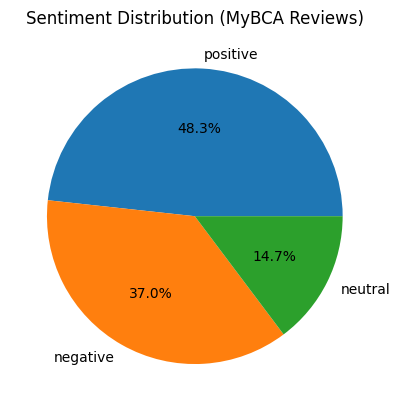

In [ ]:
import matplotlib.pyplot as plt

counts = clean_df['polarity'].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Sentiment Distribution (MyBCA Reviews)')

plt.show()

In [ ]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_cleaningText,text_casefoldingText,text_fixslangwords,text_tokenizingText,text_filteringText,text_final,polarity_score,polarity
3,20b76818-e49f-46fb-923f-52baba62a0b3,Er Pranajaya,https://play-lh.googleusercontent.com/a/ACg8oc...,LEMOOOOOOOOTTTTTTTTTTTT mau sampai kapan? gak ...,1,0,2.15.1,2026-04-12 08:21:01,Mohon maaf atas ketidaknyamanannya. Dipastikan...,2026-04-12 08:37:31,2.15.1,LEMOT mau sampai kapan gak ada perbaikan kah,lemot mau sampai kapan gak ada perbaikan kah,lambat mau sampai kapan tidak ada perbaikan kah,"[lambat, mau, sampai, kapan, tidak, ada, perba...","[lambat, tidak, ada, perbaikan]",lambat tidak ada perbaikan,-12,negative
4,71265f80-7408-467f-86de-c8da033e1085,Fadzri Apryanto,https://play-lh.googleusercontent.com/a-/ALV-U...,tolong donk pas tambah nomer nyari nomer indo ...,2,0,2.15.1,2026-04-12 07:57:46,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-04-12 08:04:28,2.15.1,tolong donk pas tambah nomer nyari nomer indo ...,tolong donk pas tambah nomer nyari nomer indo ...,tolong dong pas tambah nomor cari nomor indo k...,"[tolong, dong, pas, tambah, nomor, cari, nomor...","[tolong, pas, nomor, cari, nomor, indo, tidak,...",tolong pas nomor cari nomor indo tidak ada ada...,-22,negative
6,1a29e38e-542d-4481-9716-3d4e49611b27,Dat Atamimi,https://play-lh.googleusercontent.com/a-/ALV-U...,mantap,5,0,2.15.1,2026-04-12 07:08:44,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-04-12 07:18:05,2.15.1,mantap,mantap,mantap,[mantap],[mantap],mantap,2,positive
9,0a987c08-65e3-4cad-b0cc-b692e7da7ea1,Galang Sky,https://play-lh.googleusercontent.com/a/ACg8oc...,"buruk, pas login gak terima OTP, 2 mingguan sk...",1,0,2.15.1,2026-04-12 06:32:06,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2026-04-12 07:18:29,2.15.1,buruk pas login gak terima OTP mingguan skrng ...,buruk pas login gak terima otp mingguan skrng ...,buruk pas masuk tidak terima kode otp mingguan...,"[buruk, pas, masuk, tidak, terima, kode, otp, ...","[buruk, pas, masuk, tidak, terima, kode, otp, ...",buruk pas masuk tidak terima kode otp mingguan...,-3,negative
12,2df132ff-d4d7-47de-bc0b-ae80d2a0a2c6,Hikam Jurus sapu sapu,https://play-lh.googleusercontent.com/a/ACg8oc...,"habis up kok salah mulu masukin ID nya woy,kir...",1,0,2.15.1,2026-04-12 04:28:08,Mohon maaf atas ketidaknyamanannya. Saran dan ...,2026-04-12 04:49:10,2.15.1,habis up kok salah mulu masukin ID nya woy kir...,habis up kok salah mulu masukin id nya woy kir...,habis up kok salah mulu masukin id nya woy kir...,"[habis, up, kok, salah, mulu, masukin, id, nya...","[habis, salah, mulu, masukin, id, kirim, email...",habis salah mulu masukin id kirim email kaga,4,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,23aa7e2a-fda5-4b58-ad40-3ed3216b0b59,roy wirawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Done,5,0,1.27.1,2024-10-10 10:04:40,Thank you for the review. We hope that the myB...,2024-10-10 11:02:34,1.27.1,Done,done,done,[done],[done],done,0,neutral
19996,99e54537-8b12-409e-a0b9-69aad3a662ef,Gle Ari Channel.,https://play-lh.googleusercontent.com/a-/ALV-U...,Baru di update ..update lagi aja.... Sebulan m...,5,0,1.26.1,2024-10-10 09:44:12,Mohon maaf atas ketidaknyamanannya. Untuk hal ...,2024-10-10 09:54:46,1.26.1,Baru di update update lagi aja Sebulan mau brp...,baru di update update lagi aja sebulan mau brp...,baru di pembaruan pembaruan lagi saja sebulan ...,"[baru, di, pembaruan, pembaruan, lagi, saja, s...","[pembaruan, pembaruan, sebulan, brpa, kli, min...",pembaruan pembaruan sebulan brpa kli minimal,5,positive
19997,632dd15c-c754-49aa-83a5-c6f12de0e61f,Lukman Hakim,https://play-lh.googleusercontent.com/a/ACg8oc...,So far so good. Cm kenapa harus ada 2 apk. Kan...,1,3,1.27.1,2024-10-10 09:12:30,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2024-10-10 09:41:24,1.27.1,So far so good Cm kenapa harus ada

In [ ]:
X = clean_df['text_final']
y = clean_df['polarity']

**PERCOBAAN 1:**

FEATURE EXTRACTION: TF-IDF

PELATIHAN: RANDOM FOREST

PEMBAGIAN DATA: 80:20

accuracy_train: 0.9822910019144863

accuracy_test: 0.8557753669432036


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=1000, min_df=30, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

In [ ]:
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

In [ ]:
features_df

,ad,ada,admin,akses,aksesibilitas,aktif,akun,alasan,alhamdulillah,aman,...,vermuk,versi,via,video,virtual,wa,wajah,wallet,whatsapp,wifi
0,0.0,0.365247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.409663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15665,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15666,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15667,0.0,0.400314,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15668,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()

In [ ]:
random_forest.fit(X_train.toarray(), y_train)

RandomForestClassifier()

In [ ]:
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

In [ ]:
print('Random Forest - accuracy_trainv:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_trainv: 0.9822910019144863
Random Forest - accuracy_test: 0.8592852584556477


**PERCOBAAN 2:**

FEATURE EXTRACTION: TF-IDF

PELATIHAN: SVM

PEMBAGIAN DATA: 80:20

accuracy_train: 0.8867262284620293

accuracy_test: 0.8733248245054244

In [ ]:
from sklearn.model_selection import train_test_split

X_trainSVM, X_testSVM, y_trainSVM, y_testSVM = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_trainSVM.toarray(), y_trainSVM)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred_train_svm = svm_model.predict(X_trainSVM.toarray())
y_pred_test_svm = svm_model.predict(X_testSVM.toarray())

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_train_svm = accuracy_score(y_pred_train_svm, y_trainSVM)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_testSVM)

In [ ]:
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)

SVM - accuracy_train: 0.8867262284620293
SVM - accuracy_test: 0.8733248245054244


**PERCOBAAN 3:**

FEATURE EXTRACTION: TF-IDF

PELATIHAN: XGBOOST

PEMBAGIAN DATA: 80:20

accuracy_train: 0.9204690491384812

accuracy_test: 0.8675813656668794

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train_xgb)
y_test_xgb = le.transform(y_test_xgb)

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

xgb_model.fit(X_train_xgb, y_train_xgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:00:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_train_xgb = xgb_model.predict(X_train_xgb)
y_pred_test_xgb = xgb_model.predict(X_test_xgb)

In [ ]:
accuracy_train_xgb = accuracy_score(y_pred_train_xgb, y_train_xgb)
accuracy_test_xgb = accuracy_score(y_pred_test_xgb, y_test_xgb)

print('XGBoost (TF-IDF) - accuracy_train:', accuracy_train_xgb)
print('XGBoost (TF-IDF) - accuracy_test:', accuracy_test_xgb)

XGBoost (TF-IDF) - accuracy_train: 0.9204690491384812
XGBoost (TF-IDF) - accuracy_test: 0.8675813656668794


**PERCOBAAN 4:**

FEATURE EXTRACTION: TF-IDF

PELATIHAN: RANDOM FOREST

PEMBAGIAN DATA: 90:10

accuracy_train: 0.9819187406934695

accuracy_test: 0.8608806636885769

In [ ]:
from sklearn.model_selection import train_test_split

X_train_rf_9010, X_test_rf_9010, y_train_rf_9010, y_test_rf_9010 = train_test_split(X_tfidf, y, test_size=0.1, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_9010 = RandomForestClassifier(random_state=42)

In [ ]:
random_forest_9010.fit(X_train_rf_9010.toarray(), y_train_rf_9010)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_train_rf_9010 = random_forest_9010.predict(X_train_rf_9010.toarray())
y_pred_test_rf_9010 = random_forest_9010.predict(X_test_rf_9010.toarray())

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_train_rf_9010 = accuracy_score(y_pred_train_rf_9010, y_train_rf_9010)
accuracy_test_rf_9010 = accuracy_score(y_pred_test_rf_9010, y_test_rf_9010)

In [ ]:
print('Random Forest (TF-IDF 90:10) - accuracy_train:', accuracy_train_rf_9010)
print('Random Forest (TF-IDF 90:10) - accuracy_test:', accuracy_test_rf_9010)

Random Forest (TF-IDF 90:10) - accuracy_train: 0.9819187406934695
Random Forest (TF-IDF 90:10) - accuracy_test: 0.8608806636885769


**PERCOBAAN 5:**

FEATURE EXTRACTION: TF-IDF

PELATIHAN: XGBOOST

PEMBAGIAN DATA: 90:10

accuracy_train: 0.9172516485854073

accuracy_test: 0.8647096362476069

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

X_train_xgb_9010, X_test_xgb_9010, y_train_xgb_9010, y_test_xgb_9010 = train_test_split(X_tfidf, y, test_size=0.1, random_state=42)

In [ ]:
le_9010 = LabelEncoder()

In [ ]:
y_train_xgb_9010 = le_9010.fit_transform(y_train_xgb_9010)

In [ ]:
y_test_xgb_9010 = le_9010.transform(y_test_xgb_9010)

In [ ]:
xgb_model_9010 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

In [ ]:
xgb_model_9010.fit(X_train_xgb_9010, y_train_xgb_9010)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:54:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_train_xgb_9010 = xgb_model_9010.predict(X_train_xgb_9010)
y_pred_test_xgb_9010 = xgb_model_9010.predict(X_test_xgb_9010)

In [ ]:
accuracy_train_xgb_9010 = accuracy_score(y_pred_train_xgb_9010, y_train_xgb_9010)
accuracy_test_xgb_9010 = accuracy_score(y_pred_test_xgb_9010, y_test_xgb_9010)

In [ ]:
print('XGBoost (TF-IDF 90:10) - accuracy_train:', accuracy_train_xgb_9010)
print('XGBoost (TF-IDF 90:10) - accuracy_test:', accuracy_test_xgb_9010)

XGBoost (TF-IDF 90:10) - accuracy_train: 0.9172516485854073
XGBoost (TF-IDF 90:10) - accuracy_test: 0.8647096362476069


**PERCOBAAN 6:**

FEATURE EXTRACTION: TF-IDF

PELATIHAN: LOGISTIC REGRESSION

PEMBAGIAN DATA: 80:20

accuracy_train: 0.882498404594767

accuracy_test: 0.8746011486917677

In [ ]:
from sklearn.model_selection import train_test_split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
logistic_regression.fit(X_train_lr, y_train_lr)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_train_lr = logistic_regression.predict(X_train_lr)
y_pred_test_lr = logistic_regression.predict(X_test_lr)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train_lr)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test_lr)

In [ ]:
print('Logistic Regression (TF-IDF) - accuracy_train:', accuracy_train_lr)
print('Logistic Regression (TF-IDF) - accuracy_test:', accuracy_test_lr)

Logistic Regression (TF-IDF) - accuracy_train: 0.882498404594767
Logistic Regression (TF-IDF) - accuracy_test: 0.8746011486917677


**PERCOBAAN 7:**

FEATURE EXTRACTION: Bag of Words

PELATIHAN: LOGISTIC REGRESSION

PEMBAGIAN DATA: 80:20

accuracy_train: 0.8709317166560306

accuracy_test: 0.8580089342693044

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=1000, min_df=30, max_df=0.8)

In [ ]:
X_bow = bow_vectorizer.fit_transform(X)

In [ ]:
print('Shape of Bag of Words features:', X_bow.shape)

Shape of Bag of Words features: (15670, 449)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train_bow_lr, X_test_bow_lr, y_train_bow_lr, y_test_bow_lr = train_test_split(X_bow, y, test_size=0.2, random_state=42)

In [ ]:
logistic_regression_bow = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
logistic_regression_bow.fit(X_train_bow_lr, y_train_bow_lr)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_train_bow_lr = logistic_regression_bow.predict(X_train_bow_lr)
y_pred_test_bow_lr = logistic_regression_bow.predict(X_test_bow_lr)

In [ ]:
accuracy_train_bow_lr = accuracy_score(y_pred_train_bow_lr, y_train_bow_lr)
accuracy_test_bow_lr = accuracy_score(y_pred_test_bow_lr, y_test_bow_lr)

In [ ]:
print('Logistic Regression (Bag of Words) - accuracy_train:', accuracy_train_bow_lr)
print('Logistic Regression (Bag of Words) - accuracy_test:', accuracy_test_bow_lr)

Logistic Regression (Bag of Words) - accuracy_train: 0.8709317166560306
Logistic Regression (Bag of Words) - accuracy_test: 0.8580089342693044


**PERCOBAAN 8:**

FEATURE EXTRACTION: Bag of Words

PELATIHAN: RANDOM FOREST

PEMBAGIAN DATA: 80:20

accuracy_train: 0.9826100829610721

accuracy_test: 0.8560944479897894

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_bow_rf, X_test_bow_rf, y_train_bow_rf, y_test_bow_rf = train_test_split(X_bow, y, test_size=0.2, random_state=42)

In [ ]:
random_forest_bow = RandomForestClassifier(random_state=42)

In [ ]:
random_forest_bow.fit(X_train_bow_rf.toarray(), y_train_bow_rf)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_train_bow_rf = random_forest_bow.predict(X_train_bow_rf.toarray())
y_pred_test_bow_rf = random_forest_bow.predict(X_test_bow_rf.toarray())

In [ ]:
accuracy_train_bow_rf = accuracy_score(y_pred_train_bow_rf, y_train_bow_rf)
accuracy_test_bow_rf = accuracy_score(y_pred_test_bow_rf, y_test_bow_rf)

In [ ]:
print('Random Forest (Bag of Words) - accuracy_train:', accuracy_train_bow_rf)
print('Random Forest (Bag of Words) - accuracy_test:', accuracy_test_bow_rf)

Random Forest (Bag of Words) - accuracy_train: 0.9826100829610721
Random Forest (Bag of Words) - accuracy_test: 0.8560944479897894


**PERCOBAAN 9:**

FEATURE EXTRACTION: Bag of Words

PELATIHAN: SVM

PEMBAGIAN DATA: 80:20

accuracy_train: 0.8917517549457562

accuracy_test: 0.8720485003190811

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X_train_bow_svm, X_test_bow_svm, y_train_bow_svm, y_test_bow_svm = train_test_split(X_bow, y, test_size=0.2, random_state=42)

In [ ]:
svm_model_bow = SVC(kernel='linear', random_state=42)

In [ ]:
svm_model_bow.fit(X_train_bow_svm, y_train_bow_svm)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred_train_bow_svm = svm_model_bow.predict(X_train_bow_svm)
y_pred_test_bow_svm = svm_model_bow.predict(X_test_bow_svm)

In [ ]:
accuracy_train_bow_svm = accuracy_score(y_pred_train_bow_svm, y_train_bow_svm)
accuracy_test_bow_svm = accuracy_score(y_pred_test_bow_svm, y_test_bow_svm)

In [ ]:
print('SVM (Bag of Words) - accuracy_train:', accuracy_train_bow_svm)
print('SVM (Bag of Words) - accuracy_test:', accuracy_test_bow_svm)

SVM (Bag of Words) - accuracy_train: 0.8917517549457562
SVM (Bag of Words) - accuracy_test: 0.8720485003190811


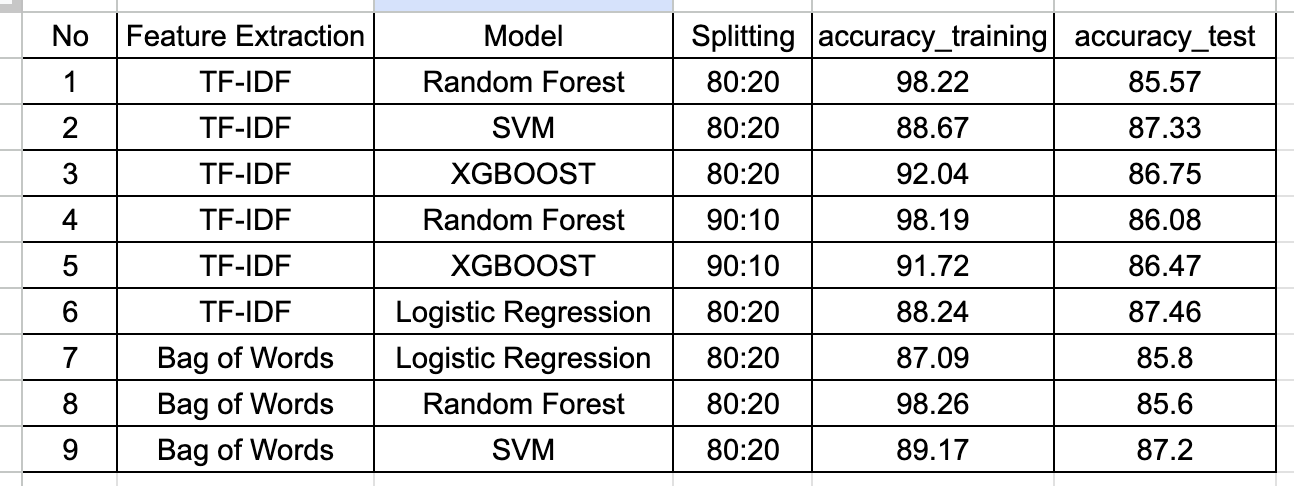

In [ ]:
!pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.6.0.54.57
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cf